
===== DECISION TREE: DIFFERENT max_depth =====

max_depth = 1
accuracy : 0.8333333333333334
precision: 1.0
recall   : 0.6666666666666666
f1-score : 0.8
----------------------------------------
max_depth = 2
accuracy : 0.8333333333333334
precision: 1.0
recall   : 0.6666666666666666
f1-score : 0.8
----------------------------------------
max_depth = 3
accuracy : 0.8333333333333334
precision: 1.0
recall   : 0.6666666666666666
f1-score : 0.8
----------------------------------------
max_depth = 4
accuracy : 0.8333333333333334
precision: 1.0
recall   : 0.6666666666666666
f1-score : 0.8
----------------------------------------
max_depth = 5
accuracy : 0.8333333333333334
precision: 1.0
recall   : 0.6666666666666666
f1-score : 0.8
----------------------------------------
max_depth = 6
accuracy : 0.8333333333333334
precision: 1.0
recall   : 0.6666666666666666
f1-score : 0.8
----------------------------------------

TABLE:
   max_depth  accuracy  precision    recall  f1_score
0          1  0.833

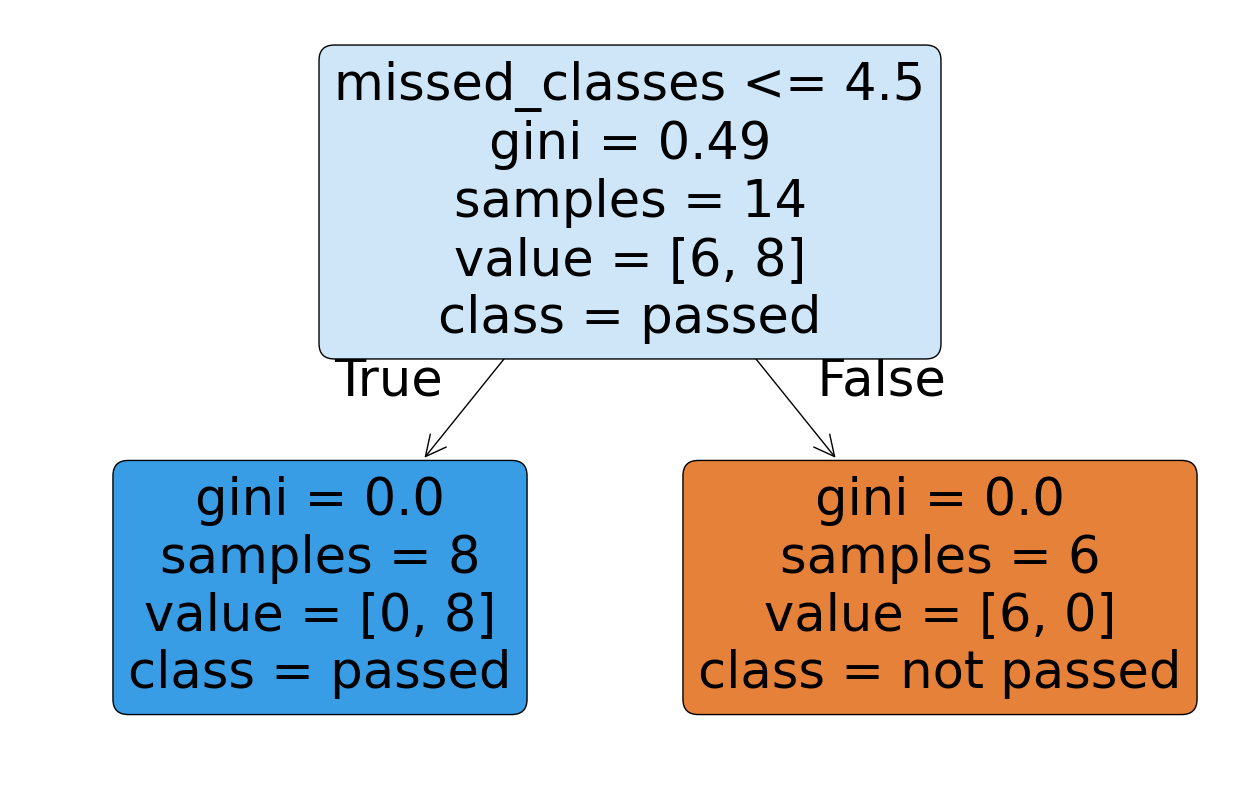

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

data = {
    "attendance": [90, 85, 40, 60, 75, 30, 95, 50, 80, 45, 88, 35, 70, 65, 92, 55, 78, 20, 83, 58],
    "homewordks_done": [9, 8, 2, 4, 7, 1, 10, 3, 8, 2, 9, 1, 6, 5, 10, 4, 7, 0, 8, 3],
    "test_score": [88, 80, 35, 55, 72, 25, 95, 45, 78, 40, 85, 30, 68, 60, 90, 50, 74, 20, 82, 48],
    "practice_hours": [20, 18, 5, 8, 15, 3, 25, 6, 17, 4, 19, 2, 12, 10, 22, 7, 14, 1, 18, 6],
    "missed_classes": [1, 2, 10, 6, 3, 12, 0, 8, 2, 9, 1, 11, 4, 5, 0, 7, 3, 15, 2, 8],
    "activity_score": [9, 8, 3, 5, 7, 2, 10, 4, 8, 3, 9, 2, 6, 6, 10, 5, 7, 1, 8, 4],
    "passed": [1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)

X = df.drop("passed", axis=1)
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("\n===== DECISION TREE: DIFFERENT max_depth =====\n")

tree_results = []

for depth in range(1, 7):

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    tree_results.append([depth, accuracy, precision, recall, f1])

    print(f"max_depth = {depth}")
    print("accuracy :", accuracy)
    print("precision:", precision)
    print("recall   :", recall)
    print("f1-score :", f1)
    print("-" * 40)

tree_df = pd.DataFrame(
    tree_results,
    columns=["max_depth", "accuracy", "precision", "recall", "f1_score"]
)

print("\nTABLE:")
print(tree_df)

print("\n===== RANDOM FOREST =====\n")

forest_results = []

for n in [10, 50, 100, 200]:

    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    forest_results.append([n, accuracy, precision, recall, f1])

    print(f"n_estimators = {n}")
    print("accuracy :", accuracy)
    print("precision:", precision)
    print("recall   :", recall)
    print("f1-score :", f1)
    print("-" * 40)

forest_df = pd.DataFrame(
    forest_results,
    columns=["n_estimators", "accuracy", "precision", "recall", "f1_score"]
)

print("\nTABLE:")
print(forest_df)

print("\n===== MODEL COMPARISON =====\n")

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

print(comparison_df)

best_model = comparison_df.loc[
    comparison_df["F1-score"].idxmax()
]

print("\nBEST MODEL BY F1-SCORE:")
print(best_model)

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

plt.figure(figsize=(16, 10))

plot_tree(
    tree_model,
    filled=True,
    feature_names=X.columns,
    class_names=["not passed", "passed"],
    rounded=True
)

plt.show()

In [ ]:
# Чем Decision Tree отличается от Logistic Regression?
# дерево использует условие, а регрессия математическую формулу

# Чем Decision Tree отличается от KNN?
# дерево может заранее создать модель и в последующем работать быстрее, а knn каждый раз будет искать соседей, что делает процесс более долгим

# Почему дерево может переобучиться
# если указать новую глубину - появятся новые данные, при появлении новых данных происходит переобучение именно по этим новым обьектам

# Что произойдет если не указать max_depth
# пока есть данные - дерево будет расти, что приведет к риску

# Что делает параметр n_estimators
# это кол-во деревьев. так как каждое дерево обучается отдельно - чем их больше, тем лучше точность

# Почему лес называется ансамблевой моделью
# от слова "ансамбль" - группа моделей в лесу после обучения голосует вместе

# Почему лес обычно стабильнее одного дерева
# одно дерево может ошибиться, множество деревьев дадут более усредненный ответ

# Почему нельзя смотреть только на accuracy
# accuracy - это кол-во правильных ответов из общего кол-ва ответов. если нет баланса будет меньше точность

# Когда важнее precision
# если появляется много ложноположительных ответов

# Когда важнее recall
# так как модель при использовании recall находит все положительные ответы, он важен когда нельзя упустить положительные случаи
